In [1]:
from diffusion_models.models import diffusion_log as dd
import pandas as pd
import numpy as np
from diffusion_models.utils import common_utils as ut
import arviz as az
import os

/home/rkm160630/anaconda3/envs/ds/lib/python3.10/site-packages/pymc/sampling/jax.py:39: UserWarning: This module is experimental.
  warnings.warn("This module is experimental.")


In [2]:
from jax.lib import xla_bridge
print(xla_bridge.get_backend().platform)

cpu


In [3]:
rotation_RT = pd.read_csv(f"data/rotation_rt.csv")
rotation_RT_n = rotation_RT.loc[~rotation_RT.isna().any(axis=1),:].to_numpy()#[0:1,:]

rotation_X = pd.read_csv(f"data/rotation_ra.csv")
rotation_X_n = rotation_X.loc[~rotation_RT.isna().any(axis=1),:].astype(int).to_numpy()#[0:1,:]

In [18]:
samples_n, tune, chains, acceptance_rate = 4000, 5000, 4,0.85

posterior_chain,_ = dd.sample_posterior_params(rotation_RT_n, rotation_X_n, 
samples_n,chains=chains, sampler="PYMC", tune=tune, acceptance_rate = acceptance_rate)


2023-01-13 15:05:38,036 - Common-Utils - DEBUG - [v_m, v_s, v, a_m, a_s, a, z_m, z_s, z, ter_m, ter_s, t_er]


DEBUG:Common-Utils:[v_m, v_s, v, a_m, a_s, a, z_m, z_s, z, ter_m, ter_s, t_er]
Auto-assigning NUTS sampler...
INFO:pymc:Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
INFO:pymc:Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
INFO:pymc:Multiprocess sampling (4 chains in 4 jobs)
NUTS: [v_m, v_s, v, a_m, a_s, a, z_m, z_s, z, ter_m, ter_s, t_er]
INFO:pymc:NUTS: [v_m, v_s, v, a_m, a_s, a, z_m, z_s, z, ter_m, ter_s, t_er]


Sampling 4 chains for 5_000 tune and 4_000 draw iterations (20_000 + 16_000 draws total) took 7463 seconds.
INFO:pymc:Sampling 4 chains for 5_000 tune and 4_000 draw iterations (20_000 + 16_000 draws total) took 7463 seconds.


In [19]:
r_hat = ut.get_rhat(posterior_chain)
r_hat

,"v_m[0, 0]","v_m[0, 1]","v[0, 0]","v[0, 1]","v[1, 0]","v[1, 1]","v[2, 0]","v[2, 1]","v[3, 0]","v[3, 1]",...,"t_er[90, 0]","t_er[90, 1]","t_er[91, 0]","t_er[91, 1]","t_er[92, 0]","t_er[92, 1]","t_er[93, 0]","t_er[93, 1]","t_er[94, 0]","t_er[94, 1]"
r_hat,2.62,2.2,2.06,2.3,2.36,2.25,2.33,1.93,2.6,2.37,...,3.19,2.24,3.37,2.71,3.44,2.78,3.53,2.52,3.07,2.48


In [20]:
posterior_chain

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

<AxesSubplot: ylabel='Density'>

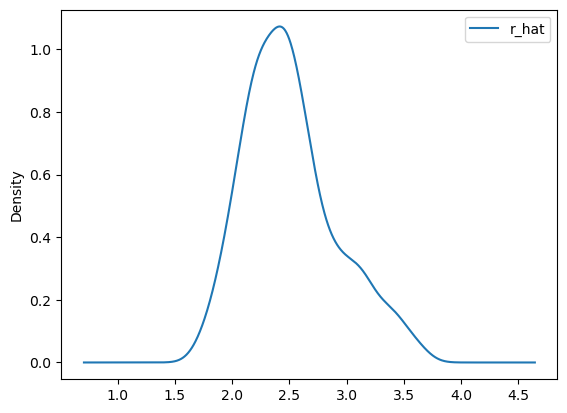

In [21]:
r_hat.T.plot(kind="kde")

In [22]:
#az.plot_trace(posterior_chain)

In [23]:
v_c_ch = ut.get_chains_for_param(posterior_chain,"v")
v_c_ch

,0,1,2,3
0,2.418623,0.982932,2.919848,-1.203490
1,0.917872,1.203838,2.197472,4.974959
2,3.432402,2.329249,3.145823,-2.303090
3,1.881593,2.614616,1.470719,4.250408
4,1.996333,2.363256,3.051728,0.990753
...,...,...,...,...
759995,0.520107,3.049528,2.262889,2.393229
759996,2.732094,2.233123,2.701504,-2.362240
759997,1.653462,1.599585,1.074055,3.268838
759998,3.080038,1.346218,3.717896,-2.101074


<AxesSubplot: >

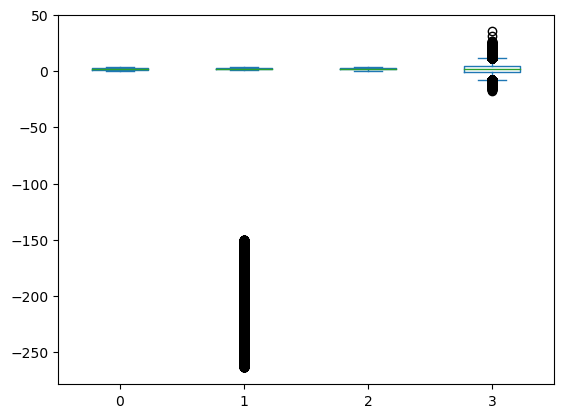

In [24]:
v_c_ch.plot(kind="box")

In [25]:
a_c_ch = ut.get_chains_for_param(posterior_chain,"a")
a_c_ch

,0,1,2,3
0,2422.931911,404.590061,1765.620772,9804.246996
1,2519.764872,595.291413,1284.244574,5369.812508
2,453.292444,436.351734,3433.754099,20767.415123
3,438.630266,357.065626,2673.748297,5314.906541
4,761.909183,2122.010673,6589.863963,17023.256628
...,...,...,...,...
759995,1995.938225,249.011986,3585.776881,292.047785
759996,3901.895542,358.375240,1733.892389,19.237329
759997,1027.915821,813.920574,1272.611131,603.292861
759998,888.538300,308.746535,1666.666622,15.547157


<AxesSubplot: >

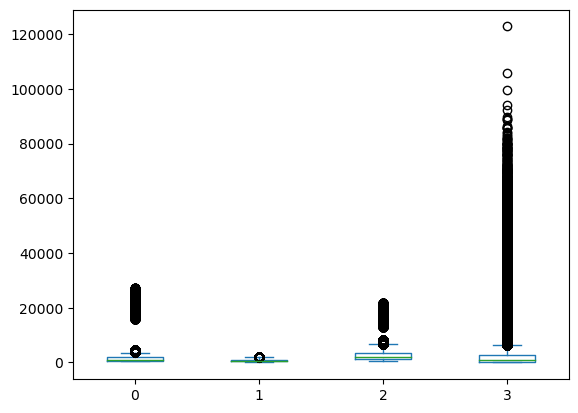

In [26]:
a_c_ch.fillna(0).plot(kind="box")

In [27]:
z_c_ch = ut.get_chains_for_param(posterior_chain,"z")
z_c_ch

,0,1,2,3
0,0.668709,0.825799,0.659032,0.462499
1,0.788872,0.626636,0.205073,0.430561
2,0.668497,0.788315,0.561265,0.519583
3,0.586283,0.260451,0.630643,0.432071
4,0.571071,0.858798,0.598320,0.447007
...,...,...,...,...
759995,0.714398,0.711761,0.343586,0.480918
759996,0.567586,0.866188,0.784974,0.555855
759997,0.653738,0.426294,0.527295,0.485604
759998,0.519330,0.677220,0.760795,0.533820


<AxesSubplot: >

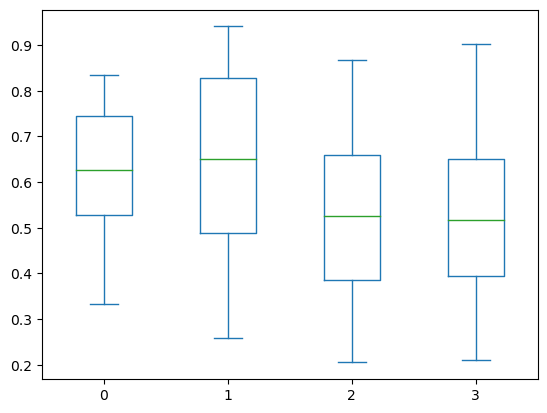

In [28]:
z_c_ch.fillna(0).plot(kind="box")

In [29]:
ter_c_ch = ut.get_chains_for_param(posterior_chain,"t_er")
ter_c_ch

,0,1,2,3
0,5.336334,4.892803,4.196734,179.860062
1,3.459101,374.537585,7.089142,27.427673
2,1.171544,5.299288,2.620702,180.439600
3,1.605020,394.193300,6.117820,27.652310
4,0.907885,8.377019,11.120209,180.714878
...,...,...,...,...
759995,1.829934,479.852723,11.721787,150.723691
759996,5.419303,12.143507,1.673949,172.737337
759997,4.469613,207.137205,11.917270,149.806076
759998,3.901359,9.926704,5.291297,172.906095


<AxesSubplot: >

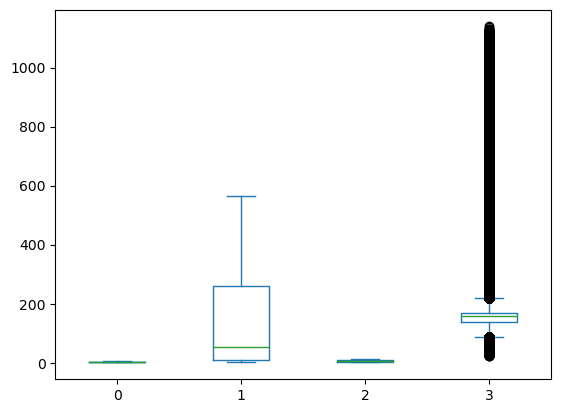

In [30]:
ter_c_ch.fillna(0).plot(kind="box")